# 6. 에지 및 직선 검출

위에서부터 순서대로 실행한다. 각 단계의 설명·코드·결과를 MD와 노트북에 같은 순서로 담았다.

- ZIP을 풀고 `Edge_Line_Notes` 폴더에서 노트북을 연다.
- 패키지가 없으면 별도 셀에서 `%pip install opencv-python numpy matplotlib`를 실행한다.
- 커널을 재시작한 뒤 첫 셀부터 실행한다. 다른 폴더에서 실행한다면 `ROOT`를 바꾼다.
- 옵시디언에서는 MD와 assets 폴더를 함께 둔다.

## 6.1 에지의 개념

- 에지는 주변에 비해 밝기가 급격하게 달라지는 부분이다.
- 검정 종이 위에 흰 종이를 올리면 둘이 만나는 곳에서 밝기가 크게 변한다.
- 물체 경계뿐 아니라 그림자·무늬·반사·잡음도 에지가 될 수 있다.
- 에지는 픽셀 집합이다. 직선 검출은 그중 일직선으로 놓인 점들을 찾는 다음 단계다.
- 에지 검출만으로 물체의 의미나 종류를 알 수는 없다.

$$
G=\sqrt{G_x^2+G_y^2},\qquad \phi=\operatorname{atan2}(G_y,G_x)
$$

$G_x,G_y$는 가로·세로 밝기 변화, $G$는 변화의 크기다. 변화 방향은 국소 에지의 접선 방향과 수직이다.

### 셀 1. 준비와 원본 로딩

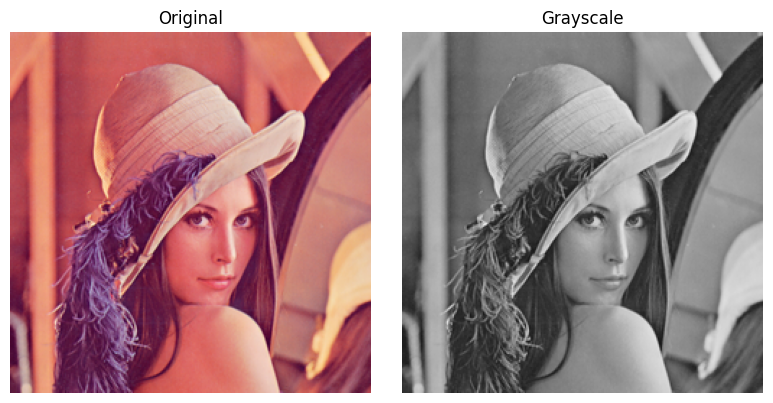

OpenCV: 5.0.0 영상: (250, 250)


In [1]:
from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()  # 필요하면 Path('/실습/폴더')로 변경
ASSETS = ROOT / 'assets'
assert (ASSETS/'Lenna.png').is_file(), 'ROOT를 확인하세요.'
bgr = cv2.imdecode(np.fromfile(ASSETS/'Lenna.png',np.uint8),cv2.IMREAD_COLOR)
assert bgr is not None
gray = cv2.cvtColor(bgr,cv2.COLOR_BGR2GRAY)

def show_panels(items, filename, cols=3):
    fig, axes = plt.subplots((len(items)+cols-1)//cols,cols,figsize=(4*cols,4*((len(items)+cols-1)//cols)),squeeze=False)
    for ax,(title,a) in zip(axes.flat,items):
        if a.ndim==2: ax.imshow(a,cmap='gray',vmin=0,vmax=255)
        else: ax.imshow(cv2.cvtColor(a,cv2.COLOR_BGR2RGB))
        ax.set_title(title);ax.axis('off')
    for ax in list(axes.flat)[len(items):]:ax.axis('off')
    fig.tight_layout();fig.savefig(ASSETS/filename,dpi=140)
    plt.show();plt.close(fig)

print('OpenCV:',cv2.__version__,'영상:',gray.shape)
show_panels([('Original',bgr),('Grayscale',gray)],'input.png',2)

## 6.2 Canny 에지 검출

### 처리 흐름

1. 가우시안으로 작은 잡음의 영향을 줄인다.
2. 밝기 변화의 크기와 방향을 계산한다.
3. 비최대 억제로 변화 방향의 주변보다 약한 반응을 줄여 얇게 만든다.
4. 두 임계값과 연결 관계로 최종 에지를 고른다.

| 후보 | 처리 |
|---|---|
| 높은 임계값보다 강함 | 강한 에지로 사용 |
| 낮은 임계값보다 약함 | 제거 |
| 두 임계값 사이 | 강한 에지와 약한 후보의 연결 사슬로 이어지면 유지 |

- 임계값은 원래 픽셀 밝기가 아니라 **미분 응답의 크기**에 적용한다.
- 낮은 임계값을 쓰면 세부와 잡음이 더 남을 수 있다.
- 높은 임계값을 쓰면 약한 경계가 사라질 수 있다.
- `L2gradient=True`이면 위 수식의 제곱합 제곱근을 사용한다. 기본 False는 $|G_x|+|G_y|$다.
- 두 설정의 임계값을 같은 의미로 비교하지 않는다.
- 이번 코드에서는 `GaussianBlur()`를 명시한다. `Canny()`가 자동으로 원하는 가우시안 전처리를 한다고 가정하지 않는다.

### 셀 2. 세 임계값 비교

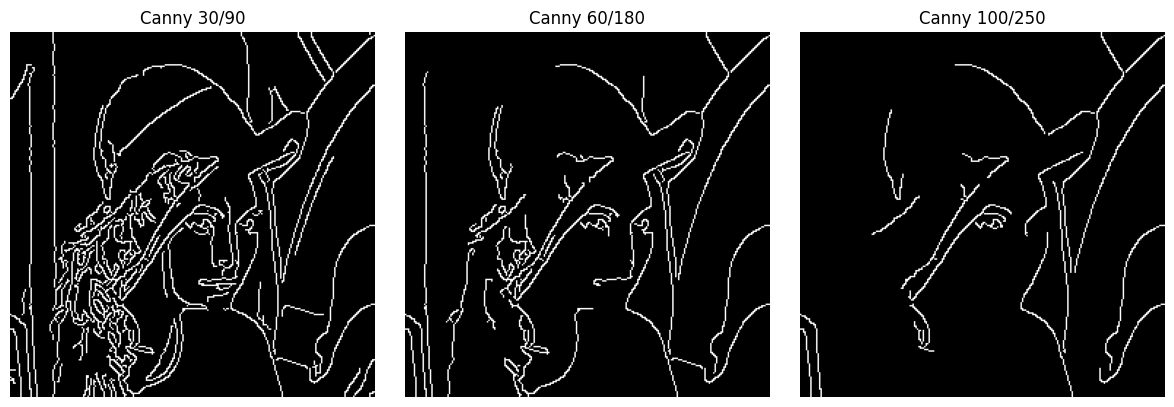

(30, 90) 에지 픽셀: 5742
(60, 180) 에지 픽셀: 3308
(100, 250) 에지 픽셀: 1934


In [2]:
blur = cv2.GaussianBlur(gray,(5,5),1.2,borderType=cv2.BORDER_REFLECT_101)
thresholds = [(30,90),(60,180),(100,250)]
edge_maps = []
for low,high in thresholds:
    edges = cv2.Canny(blur,low,high,apertureSize=3,L2gradient=True)
    assert edges.shape==gray.shape
    assert set(np.unique(edges)).issubset({0,255})
    edge_maps.append(edges)
    print((low,high),'에지 픽셀:',np.count_nonzero(edges))
show_panels([(f'Canny {lo}/{hi}',e) for (lo,hi),e in zip(thresholds,edge_maps)],'canny.png')

## 6.3 허프 변환을 이용한 직선 검출

### 점들이 같은 직선에 투표한다

- 한 에지 점을 지나는 직선은 여러 개다.
- 각 점이 자신을 지나는 직선 후보에 투표한다.
- 같은 직선 위에 점들이 많이 있으면 그 후보의 표가 모인다.

$$
\rho=x\cos\theta+y\sin\theta
$$

- $\rho$: 원점에서 직선까지의 **부호 있는 법선 거리**, 단위는 픽셀
- $\theta$: 직선의 방향이 아니라 **법선 방향의 각도**, 단위는 라디안
- 영상의 원점은 왼쪽 위이며 y는 아래로 증가한다.
- 세로선 $x=c$는 $\theta=0$, 가로선 $y=c$는 $\theta=\pi/2$로 표현된다.

### 셀 3. 교육용 투표 곡선

$y=40$인 세 점이 같은 $(\rho,\theta)=(40,90^\circ)$에 투표하는 모습을 본다. 아래는 개념용 곡선이며 OpenCV 내부 누적 배열을 추출한 그림은 아니다.

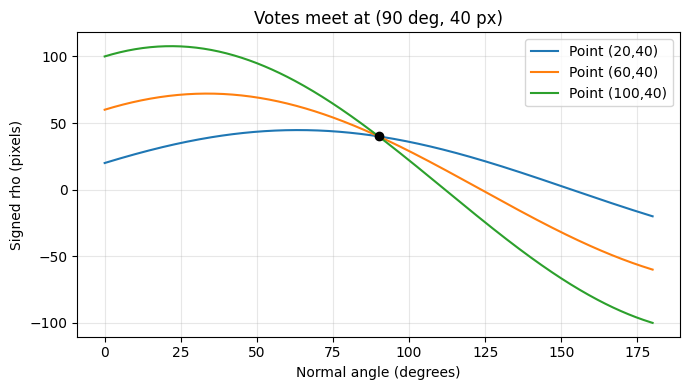

In [3]:
theta = np.linspace(0,np.pi,361)
fig,ax = plt.subplots(figsize=(7,4))
for x in [20,60,100]:
    rho = x*np.cos(theta)+40*np.sin(theta)
    ax.plot(np.rad2deg(theta),rho,label=f'Point ({x},40)')
ax.scatter([90],[40],color='black',zorder=5)
ax.set(xlabel='Normal angle (degrees)',ylabel='Signed rho (pixels)',title='Votes meet at (90 deg, 40 px)')
ax.legend();ax.grid(alpha=.3);fig.tight_layout()
fig.savefig(ASSETS/'votes.png',dpi=140);plt.show();plt.close(fig)

### 셀 4. 직선 예제 만들기

레나에는 곡선과 질감이 많으므로 허프 변환을 이해하기 위해 별도의 도형을 만든다. 수평·수직·대각선과 일부 끊어진 선을 그린다. 선에 두께가 있으므로 Canny가 양쪽 경계를 찾고, 하나의 그려진 선에서 여러 직선 후보가 나올 수 있다.

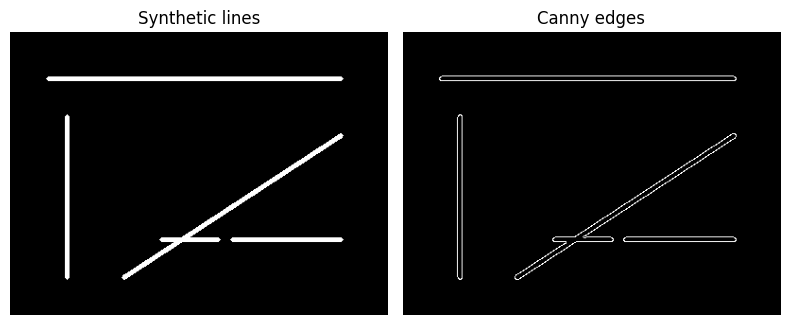

In [4]:
scene = np.zeros((300,400),np.uint8)
cv2.line(scene,(40,50),(350,50),255,3)
cv2.line(scene,(60,90),(60,260),255,3)
cv2.line(scene,(120,260),(350,110),255,3)
cv2.line(scene,(160,220),(220,220),255,3)
cv2.line(scene,(235,220),(350,220),255,3)
scene_edges = cv2.Canny(scene,50,150,L2gradient=True)
show_panels([('Synthetic lines',scene),('Canny edges',scene_edges)],'scene.png',2)

### 표준 허프 변환: HoughLines

- 결과는 `(rho, theta)`로 표현한 직선이다. 선분의 실제 끝점을 반환하지 않는다.
- 그릴 때 긴 두 끝점을 계산하지만 이는 시각화용이며 검출된 물체의 길이가 아니다.

| 인수 | 뜻 |
|---|---|
| rho=1 | 거리 누적 구간 해상도, 1픽셀 |
| theta=π/180 | 각도 누적 구간 해상도, 1도 |
| threshold=100 | 후보 선택을 위한 투표 기준 |

투표 기준은 검출 확률이나 정확한 최소 선분 길이가 아니다. 해상도를 너무 세밀하게 잡으면 투표가 여러 칸으로 분산될 수 있다.

### 셀 5. 표준 허프 검출과 표시

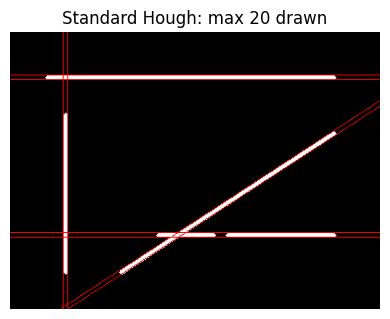

표준 허프 후보 수: 8
앞 5개 (rho, theta 라디안): [[ 52.           1.5707964 ]
 [ 47.           1.5707964 ]
 [286.           0.99483764]
 [281.           0.99483764]
 [ 62.           0.        ]]


In [5]:
def draw_standard(source, lines, max_draw=20):
    out = cv2.cvtColor(source,cv2.COLOR_GRAY2BGR)
    length = int(np.hypot(*source.shape)*2)
    if lines is not None:
        for rho,theta in lines[:max_draw,0]:
            a,b = np.cos(theta),np.sin(theta)
            x0,y0 = a*rho,b*rho
            p1=(int(round(x0-length*b)),int(round(y0+length*a)))
            p2=(int(round(x0+length*b)),int(round(y0-length*a)))
            cv2.line(out,p1,p2,(0,0,255),1)
    return out

standard = cv2.HoughLines(scene_edges.copy(),1,np.pi/180,threshold=100)
print('표준 허프 후보 수:',0 if standard is None else len(standard))
if standard is not None:
    print('앞 5개 (rho, theta 라디안):',standard[:5,0])
show_panels([('Standard Hough: max 20 drawn',draw_standard(scene,standard))],'standard.png',1)

### 확률적 허프 변환: HoughLinesP

- 전체 점의 모든 조합을 그대로 조사하는 대신 샘플링 등의 전략으로 선분을 찾는다.
- 결과는 두 끝점 `(x1, y1, x2, y2)`다.
- `minLineLength`는 받아들일 최소 선분 길이, `maxLineGap`은 같은 선분으로 연결할 점 사이의 최대 간격이다.
- 간격을 크게 허용하면 서로 다른 구조가 연결될 수 있다.
- 확률적이라는 이름이 검출 확률을 반환한다는 뜻은 아니다.

### 셀 6. 선분 검출과 간격 설정 비교

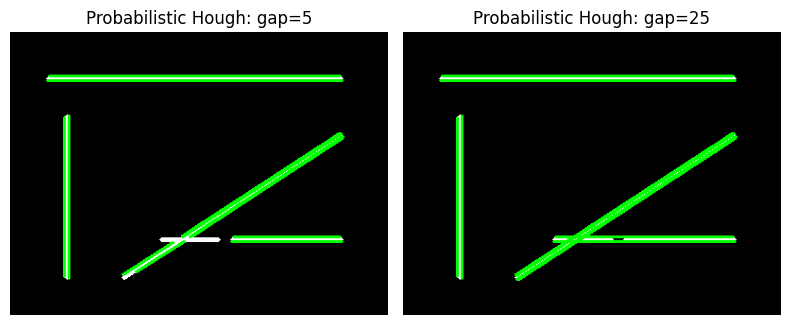

maxLineGap: 5 선분 수: 13
maxLineGap: 25 선분 수: 10


In [6]:
def draw_segments(source, lines):
    out=cv2.cvtColor(source,cv2.COLOR_GRAY2BGR)
    if lines is not None:
        for x1,y1,x2,y2 in np.asarray(lines).reshape(-1,4):
            cv2.line(out,(int(x1),int(y1)),(int(x2),int(y2)),(0,255,0),2)
    return out

segment_results={}
for gap in [5,25]:
    cv2.setRNGSeed(42)
    seg=cv2.HoughLinesP(scene_edges.copy(),1,np.pi/180,threshold=40,
                       minLineLength=40,maxLineGap=gap)
    segment_results[gap]=seg
    print('maxLineGap:',gap,'선분 수:',0 if seg is None else len(seg))
show_panels([(f'Probabilistic Hough: gap={gap}',draw_segments(scene,seg))
             for gap,seg in segment_results.items()],'segments.png',2)

### 두 방법 비교

| 구분 | 표준 허프 | 확률적 허프 |
|---|---|---|
| OpenCV 함수 | HoughLines | HoughLinesP |
| 기본 출력 | rho, theta | x1, y1, x2, y2 |
| 표현 | 끝없이 연장되는 직선 | 시작점과 끝점이 있는 선분 |
| 길이·틈 설정 | 별도 minLineLength 없음 | minLineLength, maxLineGap |
| 주의점 | 연장선이 물체 밖까지 그려짐 | 한 선이 여러 선분으로 나올 수 있음 |

둘 다 후보 수가 실제 선의 개수와 같다고 보장하지 않는다. 결과가 없으면 `None`을 반환할 수 있으므로 조건문으로 처리한다.

### 셀 7. 레나에 적용

이 예제의 목적은 레나에서 직선처럼 보이는 에지 조각을 찾는 것이다. 얼굴이나 모자를 인식하는 결과가 아니다. 두 방법은 서로 다른 투표 임계값을 사용하므로 검출 개수로 성능 순위를 매기지 않는다.

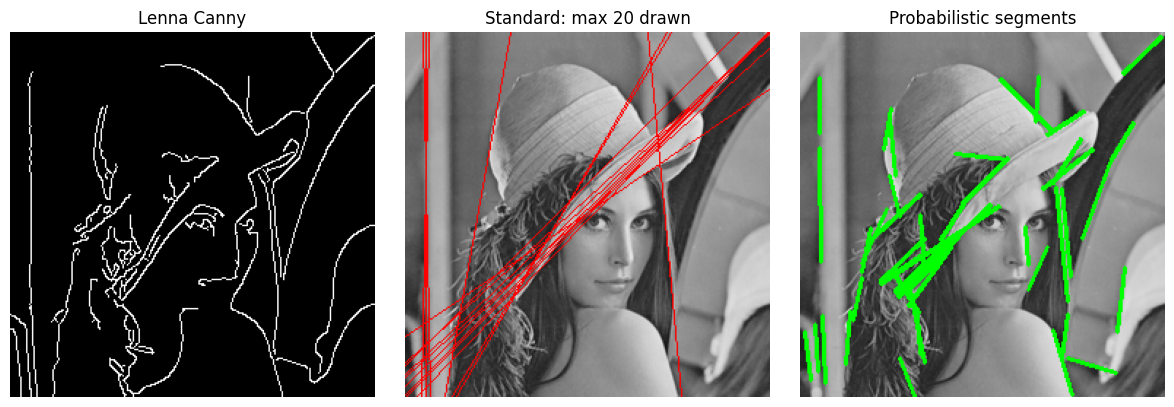

{
  "opencv": "5.0.0",
  "canny_counts": {
    "30/90": 5742,
    "60/180": 3308,
    "100/250": 1934
  },
  "synthetic_standard_count": 8,
  "synthetic_segment_counts": {
    "5": 13,
    "25": 10
  },
  "lenna_standard_count": 16,
  "lenna_segment_count": 46
}


In [7]:
lenna_edges=edge_maps[1]
ls=cv2.HoughLines(lenna_edges.copy(),1,np.pi/180,threshold=60)
cv2.setRNGSeed(42)
lp=cv2.HoughLinesP(lenna_edges.copy(),1,np.pi/180,threshold=25,
                  minLineLength=25,maxLineGap=8)
show_panels([('Lenna Canny',lenna_edges),
             ('Standard: max 20 drawn',draw_standard(gray,ls)),
             ('Probabilistic segments',draw_segments(gray,lp))],'lenna_lines.png')
summary={'opencv':cv2.__version__,
         'canny_counts':{f'{lo}/{hi}':int(np.count_nonzero(e)) for (lo,hi),e in zip(thresholds,edge_maps)},
         'synthetic_standard_count':0 if standard is None else len(standard),
         'synthetic_segment_counts':{str(g):0 if s is None else len(s) for g,s in segment_results.items()},
         'lenna_standard_count':0 if ls is None else len(ls),
         'lenna_segment_count':0 if lp is None else len(lp)}
(ROOT/'results.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print(json.dumps(summary,indent=2))

### 셀 8. 위치를 아는 직선으로 검증

시각화용 두꺼운 선과 별개로, 한 줄짜리 이진 입력을 직접 사용한다. 이 검사는 허프 좌표 해석을 확인하며 전체 영상에 대한 정확도 평가가 아니다.

In [8]:
test=np.zeros((120,160),np.uint8)
test[40,20:140]=255
known=cv2.HoughLines(test,1,np.pi/180,threshold=90)
assert known is not None
assert any(abs(float(rho)-40)<=1 and abs(float(theta)-np.pi/2)<np.deg2rad(1.1)
           for rho,theta in known[:,0])
blank=np.zeros_like(test)
assert cv2.HoughLines(blank,1,np.pi/180,30) is None
assert cv2.HoughLinesP(blank,1,np.pi/180,30,minLineLength=20,maxLineGap=3) is None
print('수평선 rho=40, theta=90도 검증 및 빈 입력 처리 통과')

수평선 rho=40, theta=90도 검증 및 빈 입력 처리 통과


## 스스로 확인하기

- [ ] 에지와 물체 경계가 항상 같지는 않음을 이해했는가?
- [ ] Canny의 중간 세기 후보가 연결 관계로 선택됨을 이해했는가?
- [ ] theta가 직선이 아닌 법선의 각도임을 알고 있는가?
- [ ] threshold와 minLineLength를 구분하는가?
- [ ] 표준 허프의 긴 표시선을 실제 선분 길이로 해석하지 않는가?

## 참고 문서

- [OpenCV — Canny Edge Detection](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)
- [OpenCV — Hough Line Transform](https://docs.opencv.org/4.x/d6/d10/tutorial_py_houghlines.html)

레나는 사용자가 제공한 파일이며 도형과 투표 곡선은 포함된 코드로 생성한다. 임계값은 이 실습용 설정으로 영상 해상도와 전처리가 바뀌면 다시 조정한다.


## 실행 확인 방식

제공 환경에서 Jupyter 커널의 소켓 생성이 제한되어, 코드 셀을 하나의 Python 실행 공간에서 순서대로 실행하고 출력·그림을 노트북에 저장했다. 모든 코드 셀과 검증문은 통과했다. 실제 Jupyter 커널에서의 Run All은 이 환경에서 확인하지 못했다.